In [1]:
from dataloader.coffee_prices_data_loader import CoffeePricesDataLoader

In [2]:
cpd = CoffeePricesDataLoader()

In [3]:
cs = cpd.get_series()

In [4]:
cs

date
1990-01-01     75.829987
1990-02-01     84.010010
1990-03-01     93.959991
1990-04-01     93.730011
1990-05-01     92.019989
                 ...    
2025-02-01    409.516500
2025-03-01    404.210476
2025-04-01    392.912727
2025-05-01    397.588636
2025-06-01    363.162381
Name: signal, Length: 426, dtype: float64

In [5]:
from visualization.series_kde_visualizer import SeriesKDEVisualizer
skde = SeriesKDEVisualizer(cs)

In [6]:
from visualization.series_visualizer import SeriesVisualizer

In [7]:
sv = SeriesVisualizer(cs)

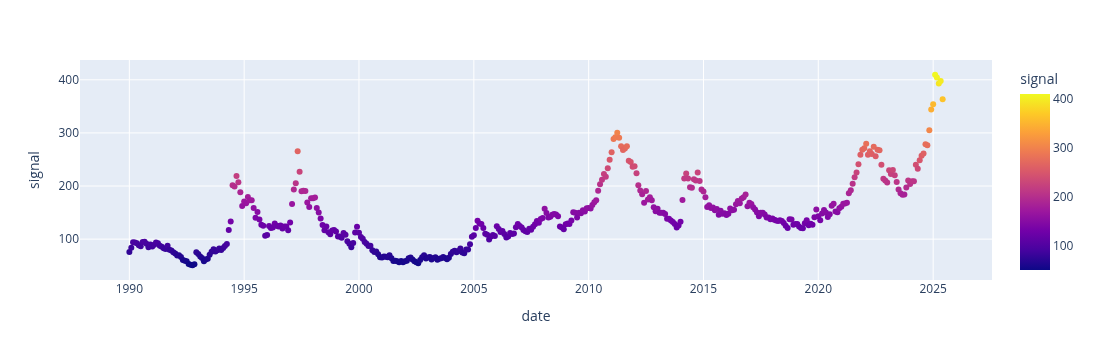

In [8]:
sv.getVisualization().show()

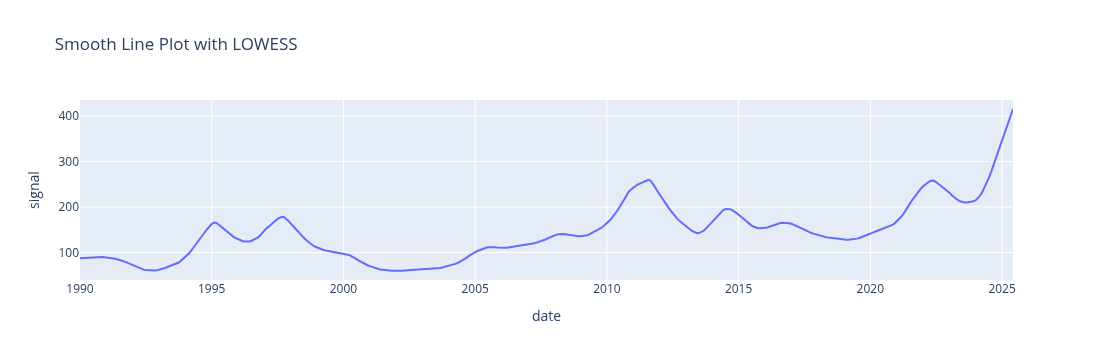

In [9]:
sv.LowessVisualizer().show()

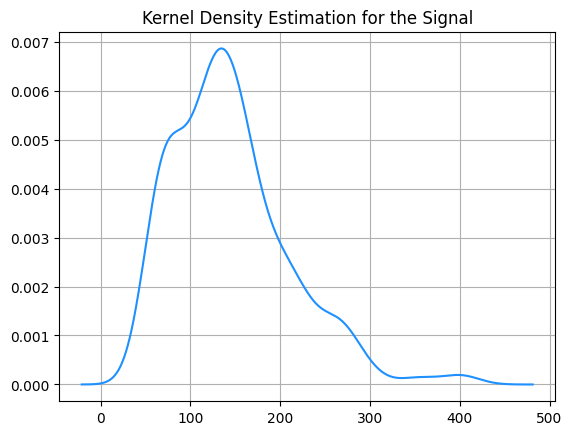

In [10]:
skde.KDEVisualizer().show()

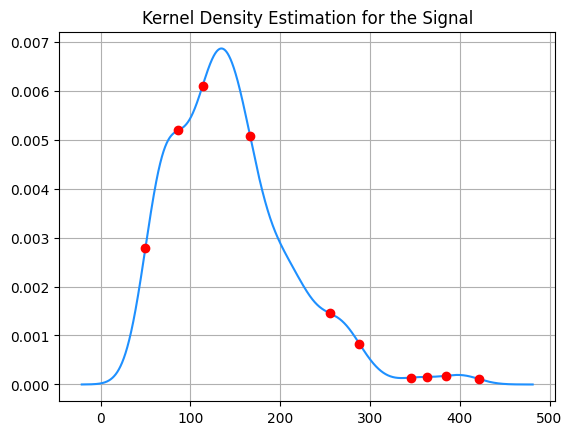

In [11]:
skde.getInflectionPointsPlot().show()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import savgol_filter
from scipy import stats
data = cs.values
kde = stats.gaussian_kde(data, bw_method = "scott") # nice feature is bandwidth selection by scott's rule is the default.

# 3. Create a range of points where you want to evaluate the PDF
xmin = data.min()
xmax = data.max()
# Create 500 equally spaced points for a smooth plot
x = np.linspace(xmin - (xmax - xmin) * 0.2, xmax + (xmax - xmin) * 0.2, 500)

# 4. Evaluate the PDF at these points
y = kde(xs)

# 5. Plot the results (optional, for visualization)
plt.plot(xs, y_values, color='dodgerblue')
plt.title('Kernel Density Estimation for the Signal')
plt.grid(True)

# 3. Smooth the curve and compute the second derivative using Savitzky-Golay filter
# window_length (must be odd) and polyorder depend on data noise level
window_length = 35
polyorder = 3 

# Compute second derivative directly
# Using deriv=2 in savgol_filter calculates the second derivative after smoothing
y_d2 = savgol_filter(y, window_length, polyorder, deriv=2)

# 4. Find points where the sign of the second derivative changes
# np.diff(np.sign(y_d2)) will be non-zero where a sign change occurs.
# np.where gets the indices of these changes.
inflection_indices = np.where(np.diff(np.sign(y_d2)))[0]

# Extract the x and y coordinates of the inflection points
inflection_points_x = x[inflection_indices]
inflection_points_y = y[inflection_indices]

print("Inflection Points (x coordinates):", inflection_points_x)

# Optional: Plot to visualize the points
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='KDE Curve')
plt.scatter(inflection_points_x, inflection_points_y, color='red', zorder=5, label='Inflection Points')
plt.title('Inflection Points on a Density Curve')
plt.xlabel('x value')
plt.ylabel('Density')
plt.legend()
plt.show()


NameError: name 'xs' is not defined

In [ ]:
skde.KDEVisualizer(bandwidth='silverman')

In [ ]:
data

In [ ]:
from visualization.autocorrelation_vis import ACFPlotter
pacfp = ACFPlotter(cs)

In [ ]:
pacfp.calc_PACF().show()

In [ ]:
pacfp.calc_ACF().show()